# 01. EDA: Geo Reviews Dataset 2023

In [1]:
import os
from pathlib import Path

# Ноутбук лежит в notebooks/, а пути в конфиге считаются от корня проекта
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data.loader import load_raw

pd.set_option("display.max_colwidth", 250)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (9, 4)
SEED = 42


def sample(frame, n=10):
    """Случайные n строк (или все, если их меньше)."""
    return frame.sample(min(n, len(frame)), random_state=SEED)


df = load_raw()
print(df.shape)
df.head()

(500000, 5)


,address,name_ru,rubrics,rating,text
0,"Екатеринбург, ул. Московская / ул. Волгоградская / ул. Печатников",Московский квартал,Жилой комплекс,3.0,"Московский квартал 2.\nШумно : летом по ночам дикие гонки. Грязно : кругом стройки, невозможно открыть окна (16 этаж! ), вечно по району летает мусор. Детские площадки убогие, на большой площади однотипные конструкции. Очень дорогая коммуналка. Ч..."
1,"Московская область, Электросталь, проспект Ленина, 29",Продукты Ермолино,"Магазин продуктов;Продукты глубокой заморозки;Магазин мяса, колбас",5.0,"Замечательная сеть магазинов в общем, хороший ассортимент, цены приемлемые, а главное качество на высоте!!! Спасибо тем, кто открыл сеть этих магазинчиков!!!!"
2,"Краснодар, Прикубанский внутригородской округ, микрорайон имени Петра Метальникова, улица Петра Метальникова, 26",LimeFit,Фитнес-клуб,1.0,"Не знаю смутят ли кого-то данные правила, но я была удивлена: \n1. Хочешь что бы твой шкаф замыкался - купи замочек\n2. Ты должен предоставить свой отпечаток пальца (полнейшая дичь) \n3. Ставят подпись на договоре с клиентом по доверенности , гра..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,Пункт проката;Прокат велосипедов;Сапсёрфинг,4.0,Хорошие условия аренды. \nДружелюбный персонал.\nНо иногда бывают неутоюбные ботинки и крепления для сноуборда .\nНо у меня редкий размер ноги
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,"Салон красоты;Визажисты, стилисты;Салон бровей и ресниц",5.0,"Топ мастер Ангелина топ во всех смыслах ) Немного волновалась перед посещением, потому что первый раз делала брови и ресницы. Ушла довольная максимально. Понравилось всё, от итога работы до отношения мастера. Всё объяснили рассказали, как проходи..."


## 1. Схема, типы, пропуски

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   address  500000 non-null  object 
 1   name_ru  499030 non-null  object 
 2   rubrics  500000 non-null  object 
 3   rating   500000 non-null  float64
 4   text     500000 non-null  object 
dtypes: float64(1), object(4)
memory usage: 19.1+ MB


In [3]:
empty = {c: int((df[c].notna() & df[c].astype(str).str.strip().eq("")).sum()) for c in df.columns}
display(pd.DataFrame({"NaN": df.isna().sum(), "empty": pd.Series(empty)}))

# Записи без названия организации: что это за места?
no_name = df[df["name_ru"].isna()]
print("Без названия:", len(no_name), f"({len(no_name) / len(df):.2%})")
display(sample(no_name, 8)[["address", "rubrics", "rating", "text"]])
display(no_name["rubrics"].value_counts().head(10))

,NaN,empty
address,0,0
name_ru,970,0
rubrics,0,0
rating,0,0
text,0,0


Без названия: 970 (0.19%)


,address,rubrics,rating,text
313466,"Самарская область, Тольятти, улица 40 лет Победы, 43В",Ресторан;Кондитерская;Кофейня,5.0,"Отличное место, тихое и уютное. Весь день можно завтракать 🤣 Супер дружелюбный персонал. Мороженое - отдельная любовь. Хотелось бы добавить в меню обычные воздушные панкейки (без банана), думаю в будущем у этого места есть огромный потенциал) Ваш..."
154539,"Московская область, Одинцовский городской округ, деревня Бородки, 47А","Детский сад, ясли",5.0,"Добрый день, моя дочь на протяжении трёх лет посещала детский сад «Голубой вагончик», у нас остались самые добрые и тёплые воспоминания! Здесь отлично организован режим и досуг детей, прогулки на свежем воздухе и вкуснейшее меню. Помимо этого, мо..."
216490,"Белгородская область, Старый Оскол, микрорайон Дубрава, квартал 3, 12",Ногтевая студия,5.0,"Прекрасная уютная студия, мастера настоящие профессионалы своего дела. Особенно хочется отметить Марину - всегда уходишь и с красивым маникюром, и с хорошим настроением! Спасибо!!!"
275281,"Краснодарский край, муниципальное образование Анапа, станица Благовещенская, Таманская улица, 99",Гостиница,5.0,"Отдыхали в середине июня 2023. Чистые свежие приятные номера, холодильник с морозильной камерой, теплый душ, белоснежное белье как в лучших домах Лондона. Нет навязчивого сервиса. Никто настоятельно не рекомендует барабулю или чурчхелу. В номере ..."
39723,"Липецк, проспект имени 60-летия СССР, 20/1","Бар, паб",4.0,"Удобное месторасположение. Помещение небольшое, внутри несколько столиков и лавочек. Но по мне так темновато. Я люблю много света, а его здесь нет. Есть пиво, соки и лёгкие закуски типа снеков. Знакомые чисто символически постоянно отмечают там с..."
461211,"Санкт-Петербург, Малый проспект Васильевского острова, 88, корп. 2",Товары для мобильных телефонов;Ремонт телефонов;Комиссионный магазин,5.0,"Всегда пользуюсь услугами Save mobile, спасибо Мужу за наводку)) защитное стекло на 14 айфон поменяли за 2 минуты, заказала чехол и кошелек, все очень оперативно, на следующий день я уже радовалась новинкам🫶🏻"
402494,"Брянск, улица Дуки, 75",Оздоровительный центр;Массажный салон;Спа-салон,5.0,"Хочу выразить огромную благодарность за пройденный авторский курс по «Ручная пластика» доктору Анне Иорданян. Обаятельный, чуткий и профессиональный преподаватель . Очень понравился курс, глубокое погружение в практику без лишней воды. ..."
266417,"Смоленск, проспект Гагарина, 10/2","Бар, паб;Кальян-бар",5.0,"Понравилась атмосфера, музыка(был диджей на момент посещения, даже потанцевали, есть танцпол в пабе), но диджей ушёл и включилась унылая музыка как будто в магазине одежды, как в примерочных. Но приветливый персонал включил нам несколько песен по..."


rubrics
Гостиница                                                                  42
Ногтевая студия                                                            31
Салон красоты                                                              29
Салон красоты;Парикмахерская;Ногтевая студия                               26
Кафе;Быстрое питание;Ресторан                                              25
Ресторан                                                                   24
Кафе                                                                       24
Косметология;Эпиляция                                                      17
Барбершоп                                                                  15
Развлекательный центр;Музей;Организация и проведение детских праздников    12
Name: count, dtype: int64

### Вывод: схема и пропуски

- 500 000 строк, 5 колонок. Пропуски только в `name_ru`: **970 строк (0,19%)**, пустых строк нет.
- Отзывы без названия ничем не выделяются: обычные рубрики (гостиницы, ногтевые студии, кафе) и в основном пятёрки. Восстановить название нечем, а `group_key` строится по названию.
- **Решение: удалить эти строки** (потеря 0,19%, перекоса нет).

## 2. Формат текста: экранирование tskv

В tskv переводы строк записываются как символы `\n`. Смотрим, что реально лежит в тексте, и нормализуем.

In [4]:
lit_n = df["text"].str.contains("\\n", regex=False)   # обратный слэш + n
real_n = df["text"].str.contains("\n", regex=False)   # настоящий перевод строки
print(f"литеральный \\n: {lit_n.sum():,} ({lit_n.mean():.2%}),  реальный перевод строки: {real_n.sum():,}")

# какие ещё обратные слэши встречаются (первый экранированный символ в тексте)
display(df["text"].str.extract(r"(\\.)", expand=False).value_counts().head(10))
display(df.loc[lit_n, "text"].head(3).tolist())

литеральный \n: 123,296 (24.66%),  реальный перевод строки: 0


text
\n    123250
\\        81
\r        24
\t        11
Name: count, dtype: int64

['Московский квартал 2.\\nШумно : летом по ночам дикие гонки. Грязно : кругом стройки, невозможно открыть окна (16 этаж! ), вечно по району летает мусор. Детские площадки убогие, на большой площади однотипные конструкции. Очень дорогая коммуналка. Часто срабатывает пожарная сигнализация. Жильцы уже не реагируют. В это время, обычно около часа, не работают лифты. Из плюсов - отличная планировка квартир ( Московская 194 ), на мой взгляд. Ремонт от застройщика на 3-. Окна вообще жуть - вместо вентиляции. По соотношению цена/качество - 3.',
 'Не знаю смутят ли кого-то данные правила, но я была удивлена: \\n1. Хочешь что бы твой шкаф замыкался - купи замочек\\n2. Ты должен предоставить свой отпечаток пальца (полнейшая дичь) \\n3. Ставят подпись на договоре с клиентом по доверенности , графу с номером доверенности оставляют пустой , а на вопрос о номере доверенности говорят номер «2»\\nВы серьезно? Номер 2? \\nПредоставить доверенность не могут, но говорят что у них в клубе «свои» довереннос

In [5]:
def normalize_text(s: pd.Series) -> pd.Series:
    s = s.fillna("").str.replace(r"\\[nrt]", " ", regex=True)   # \n, \r, \t -> пробел
    return s.str.replace(r"\s+", " ", regex=True).str.strip()


df["text_raw"] = df["text"]
df["text"] = normalize_text(df["text_raw"])

i = df.index[lit_n][0]
print("ДО:   ", repr(df.at[i, "text_raw"][:200]))
print("ПОСЛЕ:", repr(df.at[i, "text"][:200]))

ДО:    'Московский квартал 2.\\nШумно : летом по ночам дикие гонки. Грязно : кругом стройки, невозможно открыть окна (16 этаж! ), вечно по району летает мусор. Детские площадки убогие, на большой площади однот'
ПОСЛЕ: 'Московский квартал 2. Шумно : летом по ночам дикие гонки. Грязно : кругом стройки, невозможно открыть окна (16 этаж! ), вечно по району летает мусор. Детские площадки убогие, на большой площади одноти'


### Вывод: формат текста

- Литеральный `\n` есть в **123 296 отзывах (24,66%)**, настоящих переводов строки нет: tskv экранирует переносы. Кроме `\n` встречаются `\\` (81 текст), `\r` (24) и `\t` (11).
- Нормализация заменяет `\n`, `\r`, `\t` пробелом и схлопывает пробелы (пример ДО/ПОСЛЕ выше). Двойной слэш `\\` не трогаем: 81 текст из 500 тысяч, влияние ничтожно.
- **Решение:** нормализуем один раз при подготовке `reviews_clean.parquet` (это делает `audit.py`), а не в каждой модели отдельно. Нумерованные списки в отзывах после замены остаются читаемыми.

## 3. Рейтинг

Что смотрим: шкала (есть ли 0), перекос классов, «дно» для метрик.

,count,share
rating,,
0.0,200,0.04
1.0,34351,6.87
2.0,12088,2.42
3.0,21686,4.34
4.0,41160,8.23
5.0,390515,78.10


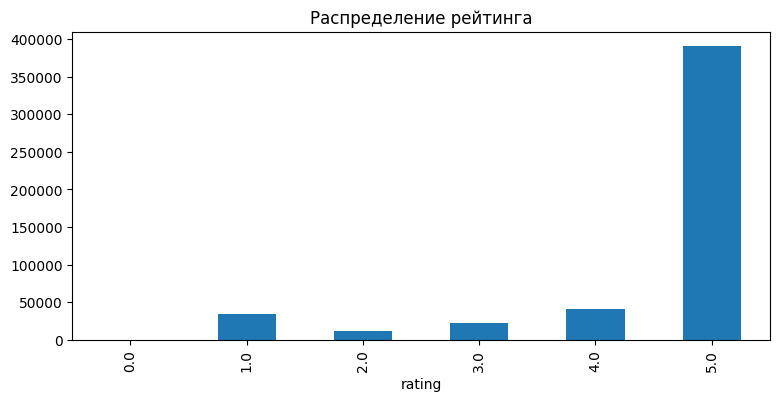

Доля пятёрок среди 1-5: 78.13%
Предсказатель 'всегда 5': accuracy ~ 0.781, macro-F1 ~ 0.175


In [6]:
vc = df["rating"].value_counts().sort_index()
display(pd.DataFrame({"count": vc, "share": (vc / len(df) * 100).round(2)}))
vc.plot.bar(title="Распределение рейтинга")
plt.show()

valid = df[df["rating"].between(1, 5)].copy()
p5 = (valid["rating"] == 5).mean()
print(f"Доля пятёрок среди 1-5: {p5:.2%}")
print(f"Предсказатель 'всегда 5': accuracy ~ {p5:.3f}, macro-F1 ~ {2 * p5 / (1 + p5) / 5:.3f}")

In [7]:
# Оценка 0: что это за отзывы?
display(sample(df[df["rating"] == 0], 12)[["name_ru", "text"]])

,name_ru,text
224438,парк Дальняя круча,"На сегодняшний день это лучший парк в нашем городе,шикарный вид на реку,для прогулки с колясками и не только,очень хорошее расположение есть где походить,для детей любого возраста различные площадки,есть туалет,что не мало важно для прогулок особ..."
26071,Регион атлетик,"Классно , и приятно , очень чисто комфортно и удобно."
62590,Музей Жостовской фабрики декоративной росписи,"Очень интересно. Шикарный музей. Много старинных подносов. Детям, да и взрослым, будет интересен мастер-класс по росписи подноса. Рекомендую к посещению."
395895,Глобус гипермаркет,Удобное расположение. Слишком большая стоянка для инвалидов. Хороший выбор продуктов. Удобно располагаются рядом строительный магазин. Много продукции собственного производства.
323062,Пляж,"Если бы не медузы, а их очень много, то всё было бы отлично."
286088,Мамуния,"Неплохой кальян, быстрый сервис, но настолки все очень поюзанные (хотелось бы обновления, тем более что много клиентов, значит есть возможность обновить развлечения для гостей). А вот випка прям убогая: маленькая комнатушка максимум на 4х человек..."
172769,Митинский радиорынок,"Были единожды и на этом точка)) Больше не приедем. Может там можно что-то и найти, но как зайдешь продавцы прям пройти не дают со своими репликами : "" что хочешь купить"" , ""давай отремонтирую"" , ""куда пошли, давайте к нам"" вобщем дурдом . Мнение ..."
422816,Арт-бухта,"Большой выбор одежды и обуви для всей семьи, и на все случаи жизни, и на любой ""кошелёк "". Есть товары и для дома. Большой магазин по площади, покупатели друг другу не мешают."
437550,Отель Station M19,"Неплохой отель, невысокие цены, но в номере плохо пахло, что-то не так с коммуникациями. Завтрак норм, овсянка, йогурт, творог, джем (2 вида), сыр, ветчина, омлет, сосиски; из овощей огурцы, помидоры; из фруктов апельсины/ грейпфруты и яблоки. Ча..."
93004,Термы,"Классное место в любое время года. Много различных саун. Есть с песком под ногами и дети там играли как будто на море. Видела пилинг для ног рыбками, но не делала. Летом есть отдельный детский бассейн с горками. Так же есть бассейн с солёной водо..."


### Вывод: рейтинг

- Шкала **0-5**, а не 1-5. Оценка 0 встречается в 200 строках (0,04%).
- Все просмотренные отзывы с оценкой 0 позитивные («лучший парк», «шикарный музей, рекомендую», «классно и приятно»). Значит, 0 означает «оценка не проставлена», а не «хуже единицы». **Решение: удалить**, задача остаётся 5-классовой (1-5).
- Распределение: 5★ 78,1%, 4★ 8,2%, 1★ 6,9%, 3★ 4,3%, 2★ 2,4%. Единиц втрое больше, чем двоек: люди чаще ставят крайние оценки. Двойки самый редкий и, вероятно, самый трудный класс.
- «Дно» для метрик: предсказатель «всегда 5» даёт accuracy 0,781 и macro-F1 0,175. Поэтому **основная метрика macro-F1**, дополнительно MAE (ошибка 1 вместо 5 хуже, чем 4 вместо 5) и F1 по классам с матрицей ошибок.
- Для Фазы 3: сравнить `class_weight=None` и `balanced` по валидации, тест не трогать.

## 4. Длины текстов

,count,mean,std,min,50%,90%,95%,99%,99.9%,max
n_chars,500000.0,301.513964,290.483214,2.0,214.0,594.0,804.0,1436.0,2774.000,19913.0
n_words,500000.0,44.099458,45.023844,1.0,30.0,89.0,122.0,221.0,432.001,3040.0


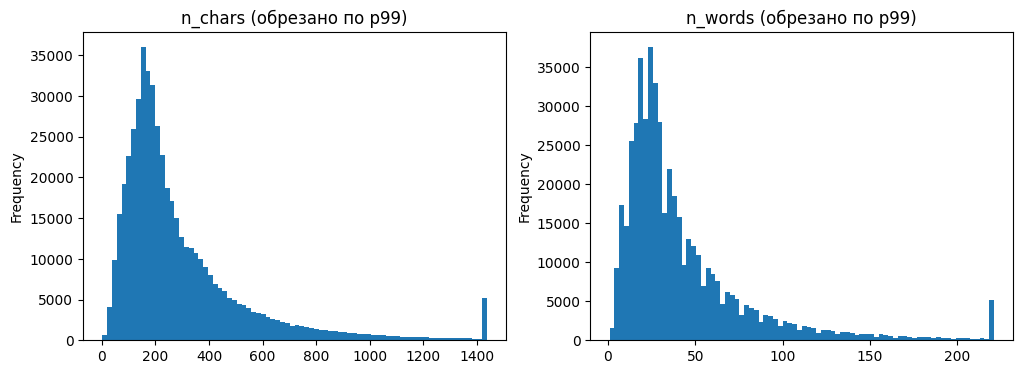

In [8]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()
valid = df[df["rating"].between(1, 5)].copy()

display(df[["n_chars", "n_words"]].describe(percentiles=[.5, .9, .95, .99, .999]).T)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, col in zip(ax, ["n_chars", "n_words"]):
    df[col].clip(upper=df[col].quantile(0.99)).plot.hist(bins=80, ax=a, title=f"{col} (обрезано по p99)")
plt.show()

n_chars        n_words       
          mean median    mean median
rating                              
1.0      534.5  402.0    83.3   62.0
2.0      509.4  381.0    79.2   59.0
3.0      426.2  302.0    65.6   46.0
4.0      335.6  237.0    50.3   35.0
5.0      264.1  200.0    37.7   28.0

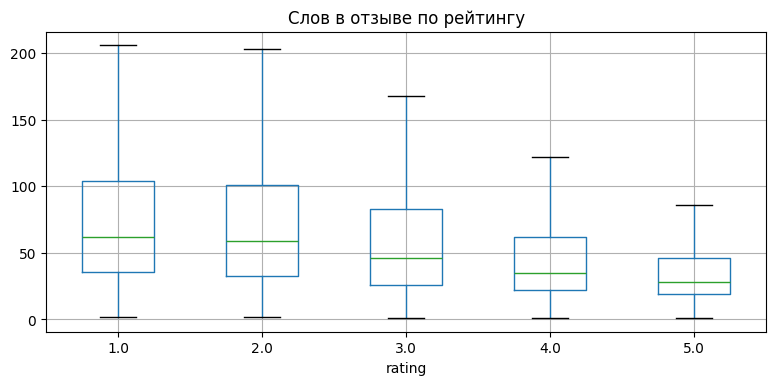

In [9]:
# Длина по рейтингу: недовольные пишут длиннее?
display(valid.groupby("rating")[["n_chars", "n_words"]].agg(["mean", "median"]).round(1))
valid.boxplot(column="n_words", by="rating", showfliers=False)
plt.suptitle("")
plt.title("Слов в отзыве по рейтингу")
plt.show()

In [10]:
print("< 3 слов:", (df["n_words"] < 3).sum(), "| < 5 слов:", (df["n_words"] < 5).sum(), "| пустых:", (df["n_words"] == 0).sum())
display(sample(df[df["n_words"] < 4], 10)[["rating", "text"]])
display(df.nlargest(3, "n_chars")[["rating", "n_chars", "text"]].assign(text=lambda d: d["text"].str[:300]))

< 3 слов: 604 | < 5 слов: 3826 | пустых: 0


,rating,text
335254,4.0,Быстро и вкусно
106026,5.0,Огромный выбор парфюмерии
424628,5.0,Прекрасный магазин.
440848,3.0,"Красиво,обслуживание норм.,быстро,еда невкусная"
222238,5.0,Отличный выбор виски
482781,5.0,Все по кайфу
219595,5.0,Это просто фантастика
95592,5.0,Очень интересная экскурсия👍
163899,5.0,Уже месяц пахнет.
20127,5.0,Отличное обслуживание


,rating,n_chars,text
485362,1.0,19913,"Отвратительно 👎👎Аквалоо 3* 4,0 СанаторийАквалоо 3* 4,0 Санаторий 4 / 5 11 452 оценки · 4 785 отзывов Donara G. Опубликовано для всех 31 янв 2023 Отвратительно 👎👎 Отзывы Сначала негативные Анна Жнакина Знаток города 4 уровня 20 авг 2022 ... каждый..."
266342,3.0,13320,"Que si, que no... Многажды бывал в этом замечательном отеле, и с каждым разом всё больше и больше эта песня про тупящего влюблённого, являющаяся гимном отеля, всё точнее и точнее описывает качество отдыха. Вообще, этот гимн противоречиям максимал..."
467212,1.0,9701,"Обратилась в клинику для заключения контракта по ведению беременности почти в 7 недель 28.03.23. Мне отказали в заключении контракта и обязали оплатить консультацию гинеколога. В следующий прием 06.04.23 я заключила контракт, в приложении которог..."


### Вывод: длины текстов

- Символы: медиана 214, p90 594, p99 1436, максимум 19 913. Слова: медиана 30, p99 221, максимум 3 040. Хвост длинный, но 99% отзывов короче 222 слов.
- **Длина сильно связана с оценкой**: в среднем 83 слова у 1★ и 38 слов у 5★ (медианы 62 и 28), убывание монотонное. Следствия: длина готовый признак для бейзлайна, а при обрезке по `max_length` сильнее всего страдают негативные отзывы.
- Короткие: меньше 3 слов 604 отзыва, меньше 5 слов 3 826 (0,77%), пустых нет. Примеры («Быстро и вкусно», «Все по кайфу») нормальные отзывы. **Решение: не отбрасывать** (`--min-words 1`). Есть отзывы из одного слова, хотя README обещает их отсутствие.
- Выбросы: самый длинный отзыв (19 913 символов) скопированная страница стороннего сайта. Это единичный мусор, удалять по длине не будем: длинные тексты обрежет `max_length`.

## 5. Шум и стилистика

Эмодзи, ссылки, не-кириллица, капс и восклицательные знаки. Сравниваем по рейтингу: это заодно даёт идеи для признаков.

In [11]:
EMOJI = "[\U0001F300-\U0001FAFF\u2600-\u27BF\uFE0F]"
df["has_emoji"] = df["text"].str.contains(EMOJI)
df["has_url"] = df["text"].str.contains(r"https?://|www\.")
df["no_cyr"] = ~df["text"].str.contains("[а-яА-ЯёЁ]")
df["excl"] = df["text"].str.count("!")
letters = df["text"].str.count("[A-Za-zА-Яа-яЁё]").replace(0, np.nan)
df["caps_share"] = df["text"].str.count("[A-ZА-ЯЁ]") / letters

valid = df[df["rating"].between(1, 5)].copy()
feats = ["has_emoji", "has_url", "no_cyr", "excl", "caps_share"]
print(df[feats].mean().round(4).to_dict())
display(valid.groupby("rating")[feats].mean().round(4))
display(sample(df[df["no_cyr"]], 8)[["rating", "text"]])

{'has_emoji': 0.1163, 'has_url': 0.0001, 'no_cyr': 0.0, 'excl': 1.1481, 'caps_share': 0.0282}


,has_emoji,has_url,no_cyr,excl,caps_share
rating,,,,,
1.0,0.0698,0.0003,0.0,1.7386,0.0250
2.0,0.0731,0.0002,0.0,1.0081,0.0234
3.0,0.0633,0.0000,0.0,0.6552,0.0238
4.0,0.0594,0.0000,0.0,0.4824,0.0252
5.0,0.1307,0.0001,0.0,1.1983,0.0292


,rating,text
290494,5.0,"One of the best experience I've ever had. Fortunate to see lion, lioness, tigar, black panther, jiraff, polar bear and many other animals. (Felt kinda bad that they're caged, but overall nice experience)"
381345,5.0,"Here my story begins. One day when my friend and I have been visiting Moscow from US, we booked our appointments with Tanya Uzhakova. My friend has a very beautiful long and thick hair, however mine are opposite. The haircut and color approach co..."
38187,5.0,"A very beautiful and stylish place with a huge assortment of delicious dishes, I recommend trying sea urchins, marbled beef steak, scallops and oysters - excellent dishes, also special thanks to the chef for a very unusual presentation, kind and ..."
449623,5.0,samokee cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool cool place 🛐
162733,5.0,"I advise everyone, the best studio and photographer"
285628,5.0,Everything is perfect in this English kindergarten. Our children are in a pleasant and comfortable environment. Professional teachers are engaged in language learning with children. Easy way to learn English! Brichild has the rich english speakin...
65549,3.0,"Good budget hotel with nice rooms, but services are not that good."
42188,5.0,"Surfing at Vake Mania was an exhilarating experience! I had the chance to ride different waves, each offering its unique thrill. The highlight, however, was their exceptional boat, which undoubtedly sets them apart as the best surf club in Moscow..."


### Вывод: шум и стилистика

- Эмодзи в 11,6% отзывов. Ссылок 0,01%. Текстов без кириллицы доля округляется до нуля (единицы отзывов на английском). Чистить нечего.
- Стилистика зависит от оценки, причём **крайние оценки эмоциональнее**: эмодзи у 5★ 13,1% против 5,9-7,3% у 1-4★; восклицательных знаков на отзыв 1,74 у 1★, 1,20 у 5★, 0,48 у 4★. Доля заглавных букв (2,3-2,9%) почти не различает классы.
- **Решение:** эмодзи и пунктуацию не удаляем. Для TF-IDF по символьным n-граммам это готовые признаки, трансформер тоже их видит (проверим в Фазе 4, как токенайзер обрабатывает эмодзи: часть может превратиться в `[UNK]`).

## 6. Дубликаты

Повтор текста у разных отзывов опасен для split (один и тот же текст в train и test) и как шум разметки, если оценки у копий разные.

In [12]:
key = df["text"].str.casefold()
dup_mask = key.duplicated(keep=False) & (df["text"] != "")
print("Строк в группах дубликатов:", dup_mask.sum(), "| лишних копий:", (key.duplicated() & (df["text"] != "")).sum())

d = df[dup_mask].assign(key=key[dup_mask])
g = d.groupby("key").agg(n=("rating", "size"), n_ratings=("rating", "nunique"), n_orgs=("name_ru", "nunique"))
print("Групп дубликатов:", len(g), "| с разными оценками:", (g["n_ratings"] > 1).sum(), "| у разных организаций:", (g["n_orgs"] > 1).sum())
display(g.sort_values("n", ascending=False).head(15))
print("Полных дублей строки:", df.duplicated(subset=["name_ru", "address", "rating", "text"]).sum())

Строк в группах дубликатов: 257 | лишних копий: 159
Групп дубликатов: 98 | с разными оценками: 11 | у разных организаций: 92


,n,n_ratings,n_orgs
key,,,
хороший магазин,10,2,9
отличный магазин,8,1,8
хороший магазин.,8,2,8
очень хороший магазин,5,1,5
вежливый персонал,4,2,4
всё отлично!,4,1,4
"выражаем благодарность персоналу гостиницы. хочется отметить, что все очень доброжелательные и вежливые, поэтому создается атмосфера хорошего отдыха и отличного настроения. мы уже дважды здесь побывали, надеемся приехать еще!огромное спасибо всем!",4,1,4
"быстрое обслуживание, вежливый персонал",4,1,4
"атмосферное заведение, получил море позитивных эмоций, понравился персонал и вкусная кухня, вечер прошел в позитивном ключе.",4,1,3


Полных дублей строки: 1


### Вывод: дубликаты

- Дубликатов почти нет: 257 строк в 98 группах повторов (159 лишних копий, 0,03%), полных дублей строки 1. Датасет действительно «уникальный».
- Повторяются короткие шаблонные фразы («хороший магазин» ×10, «отличный магазин» ×8). 92 из 98 групп относятся к разным организациям, то есть это независимые отзывы, а не копипаста. 11 групп с разными оценками обычный шум разметки: «хороший магазин» пишут и при 3★, и при 5★.
- **Решение:** правило из `audit.py` (конфликтующие копии удалить целиком, из остальных оставить первую) затрагивает меньше 0,1% данных. Оставляем, чтобы в test не было точных пересечений с train.

## 7. Организации и адреса

Главный вопрос для split: отзывы об одном месте похожи друг на друга (и по оценке, и по словам). Если разнести их между train и test, метрика будет завышена.

In [13]:
def norm_key(s: pd.Series) -> pd.Series:
    s = s.fillna("").str.casefold().str.replace("ё", "е", regex=False)
    return s.str.replace(r"\s+", " ", regex=True).str.strip()


df["name_key"] = norm_key(df["name_ru"])
df["addr_key"] = norm_key(df["address"])
df["name_addr"] = df["name_key"] + " | " + df["addr_key"]
dfn = df[(df["name_key"] != "") & df["rating"].between(1, 5)].copy()

print("уникальных названий:", dfn["name_key"].nunique(),
      "| адресов:", dfn["addr_key"].nunique(),
      "| пар название+адрес:", dfn["name_addr"].nunique())

orgs = dfn.groupby("name_key").agg(
    reviews=("rating", "size"), addresses=("addr_key", "nunique"), mean_rating=("rating", "mean")
).sort_values("reviews", ascending=False)
display(orgs.head(20))

уникальных названий: 143592 | адресов: 191511 | пар название+адрес: 275093


,reviews,addresses,mean_rating
name_key,,,
пятерочка,6025,4759,4.435021
магнит,2610,2291,4.173180
красное&белое,1732,1574,4.499423
wildberries,1697,1611,4.459045
ozon,1496,1418,4.387032
перекресток,1246,648,4.362761
вкусно — и точка,1181,541,3.675699
fix price,1117,962,4.355416
пляж,1088,581,4.385110


,по названию,по название+адрес
count,143592.00,275093.00
mean,3.47,1.81
std,23.79,2.86
min,1.00,1.00
50%,1.00,1.00
90%,6.00,3.00
99%,34.00,12.00
max,6025.00,226.00


доля отзывов: топ-1 название 1.21%, топ-10 3.86%, топ-100 10.59%
сетей (название с >1 адреса): 22,211 из 143,592; их доля отзывов: 53.74%


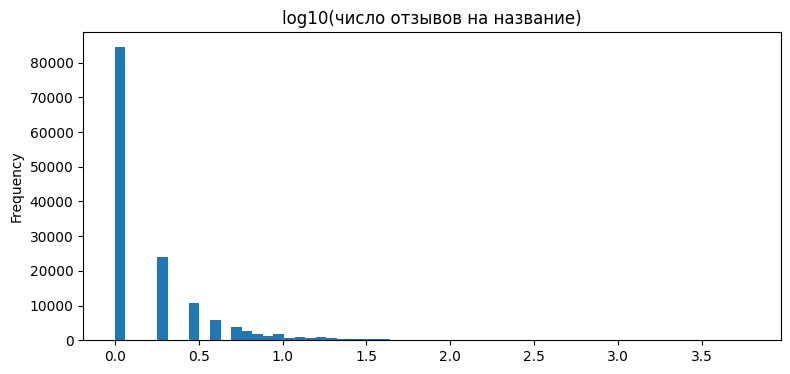

In [14]:
size_name = dfn.groupby("name_key").size()
size_pair = dfn.groupby("name_addr").size()
display(pd.DataFrame({"по названию": size_name.describe(percentiles=[.5, .9, .99]),
                      "по название+адрес": size_pair.describe(percentiles=[.5, .9, .99])}).round(2))

n = len(dfn)
top = size_name.sort_values(ascending=False)
print(f"доля отзывов: топ-1 название {top.iloc[:1].sum() / n:.2%}, топ-10 {top.iloc[:10].sum() / n:.2%}, топ-100 {top.iloc[:100].sum() / n:.2%}")

chains = orgs[orgs["addresses"] > 1]
print(f"сетей (название с >1 адреса): {len(chains):,} из {len(orgs):,}; их доля отзывов: {chains['reviews'].sum() / n:.2%}")

np.log10(size_name).plot.hist(bins=60, title="log10(число отзывов на название)")
plt.show()

In [15]:
# Первый компонент адреса (регион или город) и рубрики
dfn["place"] = dfn["address"].str.split(",").str[0]
display(dfn["place"].value_counts().head(15))

dfn["first_rubric"] = dfn["rubrics"].str.split(";").str[0]
dfn["n_rubrics"] = dfn["rubrics"].str.count(";") + 1
display(dfn["first_rubric"].value_counts().head(15))
display(dfn["n_rubrics"].describe().round(2))

place
Москва                     104541
Санкт-Петербург             52445
Московская область          49829
Краснодарский край          29571
Республика Татарстан        11638
Свердловская область        11591
Краснодар                    9050
Нижний Новгород              8537
Ленинградская область        8388
Республика Крым              8120
Ростов-на-Дону               7757
Ставропольский край          6438
Республика Башкортостан      6233
Самара                       5726
Ростовская область           5621
Name: count, dtype: int64

first_rubric
Гостиница                    42606
Ресторан                     39711
Кафе                         31194
Супермаркет                  14372
Салон красоты                11861
Магазин продуктов            11794
Быстрое питание               9628
Торговый центр                8061
Музей                         8043
Бар, паб                      7498
Парк культуры и отдыха        7442
Автосервис, автотехцентр      6187
Стоматологическая клиника     5919
Медцентр, клиника             5902
Кофейня                       5680
Name: count, dtype: int64

count    498830.00
mean          1.86
std           0.96
min           1.00
25%           1.00
50%           2.00
75%           3.00
max          12.00
Name: n_rubrics, dtype: float64

In [16]:
# Средний рейтинг по рубрикам: рубрика сама по себе несёт сигнал?
rub = dfn.groupby("first_rubric").agg(n=("rating", "size"), mean_rating=("rating", "mean"), share_1=("rating", lambda s: (s == 1).mean()))
rub = rub[rub["n"] >= 2000].sort_values("mean_rating")
display(rub.head(10).round(3))
display(rub.tail(10).round(3))

,n,mean_rating,share_1
first_rubric,,,
Автомойка,2854,4.072,0.143
Банк,3382,4.077,0.172
Быстрое питание,9628,4.088,0.132
Суши-бар,2867,4.152,0.148
Доставка еды и обедов,2826,4.168,0.151
Железнодорожный вокзал,2260,4.269,0.055
Жилой комплекс,2982,4.305,0.068
АЗС,3188,4.311,0.102
Ветеринарная клиника,3036,4.318,0.138


,n,mean_rating,share_1
first_rubric,,,
Салон красоты,11861,4.662,0.061
Достопримечательность,4483,4.669,0.023
Парк культуры и отдыха,7442,4.679,0.016
Стоматологическая клиника,5919,4.682,0.061
Театр,3135,4.753,0.019
Агентство недвижимости,2018,4.763,0.052
Музей,8043,4.773,0.014
Косметология,2186,4.790,0.038
"Детский сад, ясли",2862,4.802,0.027


### Вывод: организации, сети, рубрики

- 143 592 уникальных названия, 191 511 адресов, 275 093 пары «название + адрес» (пар больше, чем адресов: по одному адресу бывает несколько организаций, например в ТЦ).
- Крупнейшая группа по названию «Пятёрочка»: 6 025 отзывов, **1,21%** данных. Топ-10 названий 3,86%, топ-100 10,59%. Ни одна группа не мешает делению 70/15/15. Типичная группа мелкая: по названию медиана 1 отзыв, p90 6, p99 34; по «название + адрес» p90 3, p99 12, максимум 226.
- **Сети:** 22 211 названий (15,5%) имеют больше одного адреса, и на них приходится **53,7% всех отзывов**. Оговорка: среди них есть общие названия («Пляж», «Продукты», «Смотровая площадка»), которые склеивают несвязанные места. Для защиты от утечки это безопасно: группа просто получается крупнее.
- **Бренды заметно различаются по рейтингу**: KFC 3,56, «Вкусно - и точка» 3,68, «Дикси» 3,67 против «Чижика» 4,52 и «Лукойла» 4,53. Названия брендов встречаются в самих текстах, поэтому при разнесении филиалов одной сети по train и test модель получает подсказку по бренду.
- Рубрики: самые частые гостиница (8,5% отзывов), ресторан, кафе. Средний рейтинг по рубрикам от 4,07 (автомойка, банк, быстрое питание) до 4,83 (барбершоп, детский сад): тип заведения несёт сигнал, но мы предсказываем рейтинг по тексту и рубрику признаком не берём. География: Москва 21%, Санкт-Петербург 10,5%, Московская область 10%.

### Насколько организация «объясняет» оценку

Доля дисперсии рейтинга, объяснённая названием организации (для названий с >= 30 отзывов).
Чем она выше, тем опаснее случайный split: модель сможет «узнавать» места, а не оценивать текст.

отзывов в этой выборке: 149,818 (30.0%)
доля дисперсии рейтинга, объяснённая названием: 8.2%


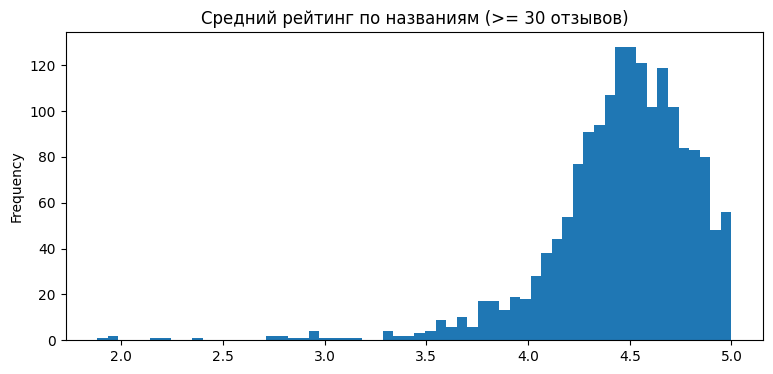

In [17]:
grp = dfn.groupby("name_key")["rating"]
big = dfn[grp.transform("size") >= 30]
total_var = big["rating"].var()
between_var = big.groupby("name_key")["rating"].transform("mean").var()
print(f"отзывов в этой выборке: {len(big):,} ({len(big) / len(dfn):.1%})")
print(f"доля дисперсии рейтинга, объяснённая названием: {between_var / total_var:.1%}")

means = big.groupby("name_key")["rating"].mean()
means.plot.hist(bins=60, title="Средний рейтинг по названиям (>= 30 отзывов)")
plt.show()

### Вывод: сколько объясняет название и выбор group_key

- Название организации объясняет **около 8%** дисперсии оценки (по названиям с не менее чем 30 отзывов, это 30% данных; число слегка завышено шумом внутри групп). Это только сдвиг «репутации бренда»; вторая часть утечки лексика конкретного места (блюда, имена персонала, улицы).

| Кандидат | Групп | Крупнейшая группа | Что закрывает |
|---|---|---|---|
| название | 143 592 | 1,21% данных | утечку и внутри места, и между филиалами сети |
| название + адрес | 275 093 | 226 отзывов (0,05%) | только утечку внутри одного места |

- **Решение: `group_key = name`** (нормализованное название). Он закрывает утечку через сети (53,7% отзывов), а группы при этом всё равно мелкие. Минусы: варианты написания («Магнит у дома» и «Магнит») не склеиваются, значит небольшая остаточная утечка останется.
- В Фазе 2 измерим её размер: разница метрики бейзлайна при случайном и при групповом split.

## 8. Прямые упоминания оценки в тексте

Если в тексте написано «ставлю 5 звёзд», задача становится тривиальной для этих отзывов. Смотрим, как часто это бывает и совпадает ли с реальной оценкой.

In [18]:
WORD2NUM = {"одну": 1, "одна": 1, "две": 2, "три": 3, "четыре": 4, "пять": 5}
PAT_DIGIT = r"(?<!\d)([1-5])\s*(?:-\s*)?(?:зв[её]зд|балл|из\s*5|/\s*5|из\s*пяти)"
PAT_VERB = r"(?:оценк\w*|ставлю|поставил\w*|поставлю|дам|даю)\s*[:\-–]?\s*([1-5])(?!\d)"
PAT_WORD = r"\b(одну|одна|две|три|четыре|пять)\s+зв[её]зд"


def mentioned_rating(text: pd.Series) -> pd.Series:
    low = text.str.lower()
    a = pd.to_numeric(low.str.extract(PAT_DIGIT, expand=False), errors="coerce")
    b = pd.to_numeric(low.str.extract(PAT_VERB, expand=False), errors="coerce")
    c = low.str.extract(PAT_WORD, expand=False).map(WORD2NUM)
    return a.fillna(b).fillna(c)


dfn["mention"] = mentioned_rating(dfn["text"])
has = dfn["mention"].notna()
print(f"с упоминанием оценки: {has.sum():,} ({has.mean():.2%})")
print(f"совпадает с реальной оценкой: {(dfn.loc[has, 'mention'] == dfn.loc[has, 'rating']).mean():.1%}")
display(pd.crosstab(dfn.loc[has, "rating"], dfn.loc[has, "mention"]))
display(sample(dfn[has], 10)[["rating", "mention", "text"]])

с упоминанием оценки: 9,413 (1.89%)
совпадает с реальной оценкой: 67.9%


mention,1.0,2.0,3.0,4.0,5.0
rating,,,,,
1.0,600,56,65,51,168
2.0,116,527,73,62,90
3.0,75,158,695,129,235
4.0,643,49,144,1086,374
5.0,53,56,193,227,3488


,rating,mention,text
443078,5.0,5.0,Вообщем в целом пиво нравится. Поставлю 5 Но иногда пиво бывает вода водой бывает и голова даже болит от него. Закуски вкусные свежие Девочки продавцы приветливые молодцы
160725,4.0,5.0,"Огромное спасибо администратору Кристине, очень отзывчивая девушка!) Расположение очень удобное, мне было комфортно добираться в любую точку города! Все круто, классно! Поставила бы 5 звёзд, но минус одна, за туалет! Он живёт своей жизнью, хочет ..."
494313,4.0,4.0,"Очень люблю магазины ВкусВилл за отличный ассортимент, качество, состав продуктов. Молочные продукты, рыбу, мясо, сладости, мороженое - все покупаю только во вкусвилле уже много лет. Конкретно в этом магазине отличный всегда выбор всего, лучше, ч..."
133065,4.0,4.0,"Мы жили не в головном корпусе, а в ""Алтайском замке +"" на ул. Славского 65. Нам всё очень понравилось! У нас был номер с терраской, выходящей прямо к маленькому бассейну. Детёныш был в восторге!!! Уборка через день! Ходили на завтрак в основной к..."
413757,5.0,5.0,"5 баллов! Интерьер достойный - в ожидании блюд интересно разглядывать качественные фото с красивыми людьми. Официант был профессионален - не навязчив и учтив. А еда? Еда это огонь - лодочка вкусна - тесто тонкое и вкусное, сыра достаточно и он пр..."
262437,4.0,1.0,"Магазин неплохой, товары действительно по хорошим ценам, не слишком широкий ассортимент продуктов, но в принципе всё есть. Сняла одну звезду так как купила масло кунжутное ёмкостью 0,25 л производителя ""Елея"", оно оказалось абсолютно не кунжутное..."
257543,1.0,1.0,"Отвратительно работает такси ! Был сделан заказ , в итоге никто не приехал и не встретил, хотя заказывали даже встречу у вагона. Моя пожилая Мама вынуждена была таскать свои много численные вещи! И так они подводили меня и раньше! . Ставлю 1 , хо..."
169418,5.0,5.0,"Здесь самый вкусный том ям! Пять звезд только за него, потому что остальное меню посредственное. А вот том ям лучший в городе!"
377034,5.0,5.0,"Отличный пункт выдачи. Всегда вежливый и приветливый администратор. Из двух пунктов расположенных рядом с моим домом, выбрала этот. За обслуживание ставлю оценку 5 звёзд."
97988,5.0,5.0,"Плюсы: Концепция и дизайн на 5 из 5! Очень атмосферно, дружелюбно, уютно, с ощущением, что ты по Аутлету в Италии гуляешь:)) Часто проводятся клёвые ивент мероприятия, охватывающие всю семью, интересно и взрослым и детям. Неплохой выбор (гармонич..."


### Вывод: прямые упоминания оценки

- Явное упоминание оценки в **9 413 отзывах (1,89%)**, упомянутое число совпадает с реальной оценкой в 67,9% случаев.
- Главная аномалия в таблице: 643 отзыва с оценкой 4 и упоминанием «1». Судя по прочитанным примерам, это «сняла одну звезду» (минус одна звезда даёт 4); то же у «поставила бы 5 звёзд, но минус одна». Регулярки не понимают вычитание. Проверить можно так: отфильтровать `mention == 1` и `rating == 4` и прочитать 20 текстов.
- Такое упоминание не утечка ярлыка, а часть текста, которую модель вправе использовать. Доля мала, в худшем случае метрика завышена на пару процентов.
- **Решение: ничего не удаляем.** В Фазе 5 (анализ ошибок) отдельно посчитаем метрику на отзывах с упоминанием оценки и без них.

## 9. Характерные слова по классам

Лог-отношение шансов слова в отзывах с оценкой 1 и 5 (по выборке). Это заранее показывает, что увидит TF-IDF бейзлайн.

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

smp = dfn.sample(min(150_000, len(dfn)), random_state=SEED)
cv = CountVectorizer(min_df=50, binary=True, lowercase=True, token_pattern=r"(?u)\b\w\w+\b")
X = cv.fit_transform(smp["text"])
vocab = np.array(cv.get_feature_names_out())
r = smp["rating"].to_numpy()


def log_odds(a: int, b: int) -> np.ndarray:
    Xa, Xb = X[r == a], X[r == b]
    pa = (np.asarray(Xa.sum(0)).ravel() + 1) / (Xa.shape[0] + 2)
    pb = (np.asarray(Xb.sum(0)).ravel() + 1) / (Xb.shape[0] + 2)
    return np.log(pa / (1 - pa)) - np.log(pb / (1 - pb))


lo = log_odds(1, 5)
order = np.argsort(lo)
pd.DataFrame({"типично для 1": vocab[order[::-1][:25]], "типично для 5": vocab[order[:25]]})

,типично для 1,типично для 5
0,роспотребнадзор,внимательное
1,обходите,просторно
2,отвратительное,атмосферное
3,ужасное,стильно
4,извинений,безболезненно
5,худший,благодарю
6,отвратительная,широкий
7,нуле,великолепное
8,полицию,классное
9,ногой,уютные


### Вывод: характерные слова

- Для 1★: «роспотребнадзор», «обходите», «отвратительное», «худший», «полицию», «извинений». Для 5★: «просторно», «атмосферное», «стильно», «благодарю», «великолепное», «уютный».
- Слова осмысленные, без названий брендов и мусора: в тексте есть реальный тональный сигнал. Негатив выражается жалобами и требованиями (полиция, Роспотребнадзор, извинения), позитив оценочными прилагательными.
- Для крайних классов лексический бейзлайн должен работать хорошо. Трудными ожидаем оценки 2-4: у них нет ярких маркеров, а отзывы смешанные.

## 10. Длина в токенах (для max_length в Фазе 4)

Нужна сеть для скачивания токенайзера rubert-tiny2 (маленький файл). Если сети нет, ячейка просто сообщит об этом.

count    20000.0
mean        67.6
std         71.7
min          3.0
50%         48.0
90%        132.0
95%        178.0
99%        325.0
max       4536.0
dtype: float64

{64: '33.84%', 128: '10.69%', 256: '1.85%', 512: '0.20%'} - доля отзывов длиннее порога


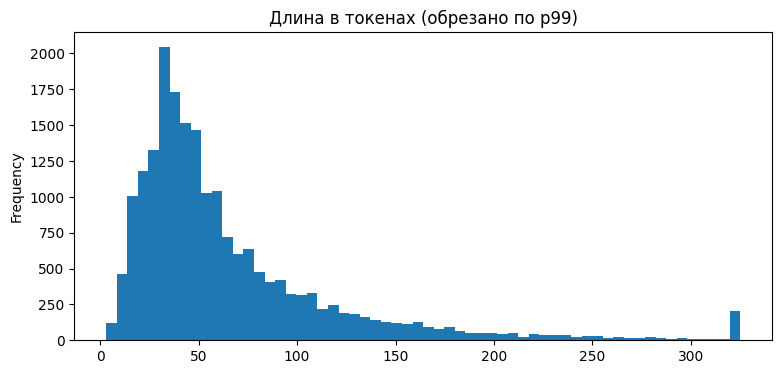

In [20]:
try:
    from transformers import AutoTokenizer

    tok = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
    tok.model_max_length = 10**6
    texts = sample(dfn[dfn["text"] != ""], 20_000)["text"].tolist()
    lens = pd.Series([len(x) for x in tok(texts, add_special_tokens=True, truncation=False)["input_ids"]])
    display(lens.describe(percentiles=[.5, .9, .95, .99]).round(1))
    print({m: f"{(lens > m).mean():.2%}" for m in (64, 128, 256, 512)}, "- доля отзывов длиннее порога")
    lens.clip(upper=lens.quantile(0.99)).plot.hist(bins=60, title="Длина в токенах (обрезано по p99)")
    plt.show()
except Exception as e:
    print("Токенайзер недоступен:", e)

### Вывод: длина в токенах (rubert-tiny2, выборка 20 000)

| Порог | Отзывов длиннее |
|---|---|
| 64 токена | 33,8% |
| 128 | 10,7% |
| 256 | 1,85% |
| 512 | 0,20% |

Медиана 48 токенов, p90 132, p95 178, p99 325.

- При `max_length=128` обрезается каждый десятый отзыв, причём в основном негативные (они длиннее). При 256 обрезается меньше 2%.
- **Решение:** брать `max_length=256` с динамическим паддингом (батчи из текстов близкой длины): время обучения определяется реальной, а не максимальной длиной, а медиана всего 48 токенов. `max_length=128` оставляем как быстрый вариант для сравнения. В `configs/transformer.yaml` заменить 128 на 256.

## 11. Читаем отзывы глазами

In [21]:
for rt in range(1, 6):
    print(f"\n===== рейтинг {rt} =====")
    for t in sample(dfn[dfn["rating"] == rt], 4)["text"]:
        print("-", t[:300])


===== рейтинг 1 =====
- Добрый день! Я советую внимательно ознакомиться с отзывами перед поступлением и подумать. Мой ребенок обучается в колледже с 2021 года. Еще ни одного года не обошлось без решения вопросов со скандалом. После одного года обучения, колледжем принимается решение о расформировании уже сложившихся групп.
- Сложное окрашивание, это у них несколько прядей и тонировка с корнями. Подстригли и окрасили как в 80 е, супер, выгляжу на всё 100...Лет... Сделали мелирование рыжего цвета и шапку на голове с тремя длинными волосинами сзади. Цена удовольствия 3300. Парикмахер Нерина
- Вроде все есть , рынок прекрасный , но видимо там законы РФ продавцам не интересны ! Оплату провести картой или получить чек об оплате не реально ! Пришлось идти снимать деньги . При чем накупили нормально и баранину и свинину , все свежее чек более 3 т мясо то хорошее вопросов нет , но такое хамств
- Цен на сайте нет, поиск не выдает даже те товары которые точно есть на сайте, дозвониться чтобы узн

### Вывод: чтение отзывов

- Негатив часто нейтрален по тону: «Цен на сайте нет, поиск не выдаёт товары, дозвониться не удалось» это 1★ без оценочных слов. Здесь бейзлайн по словам будет слаб, и это аргумент за дообучение трансформера.
- Средние классы содержат смешанные отзывы («Ярмарка отличная... Один минус, и очень большой - стоянка»): границы 3/4 и 2/3 размыты. Ожидаем путаницу соседних классов, поэтому MAE нужна рядом с macro-F1.

## 12. Выводы

| Вопрос | Решение | Основание |
|---|---|---|
| Шкала | Оставляем оценки 1-5, оценку 0 удаляем (200 строк) | Все просмотренные отзывы с 0 позитивные: оценка не проставлена |
| Метрики | Основная macro-F1, плюс MAE и F1 по классам | 78% пятёрок; «всегда 5» даёт accuracy 0,781 и macro-F1 0,175 |
| Чистка | Удаляем: оценка 0 (200), без названия (970), конфликтующие и повторные тексты (меньше 0,1%). Короткие и длинные отзывы не удаляем | Короткие отзывы нормальные; длинные обрежет `max_length`. Останется около 498,5 тыс. строк (99,7%) |
| Формат текста | `\n`, `\r`, `\t` заменяем пробелом один раз при подготовке; эмодзи и пунктуацию оставляем | Экранирование tskv в 24,7% отзывов; эмодзи и «!» связаны с оценкой |
| group_key | Нормализованное название организации (`name`) | 53,7% отзывов о сетях; бренды различаются по рейтингу на ~1 звезду; крупнейшая группа 1,21% |
| Упоминания оценки | Не удаляем; в Фазе 5 считаем метрику с ними и без | 1,89% отзывов, часть регулярок ловит «минус одна звезда» |
| max_length | 256 с динамическим паддингом; 128 как быстрый вариант | Длиннее 128 токенов 10,7% отзывов, длиннее 256 всего 1,85% |
| Признаки бейзлайна | TF-IDF по словам и символам; при желании длина, эмодзи, число «!» | Длина и стилистика зависят от оценки |
| Ожидания | 1★ и 5★ распознаются хорошо, 2-4★ трудно | Слова по классам; чтение отзывов; двоек всего 2,4% |

### Что делать дальше

1. Запустить `python -m src.data.audit` (по умолчанию `--group-key name`): получим `reports/data_audit.md` и `data/processed/reviews_clean.parquet`.
2. В `configs/data.yaml` записать `split.group_key: name`, в `configs/transformer.yaml` заменить `max_length` на 256.
3. Закоммитить ноутбук, отчёт и конфиги, затем перейти к Фазе 2 (split): отдельно измерить, сколько метрика завышается при случайном разбиении вместо группового.